<h1 align='center'>🍍 Fruits-360: High-Speed End-to-End MobileNetV2 for Flutter 📱</h1>

<div style="background-color:rgba(0, 200, 100, 0.1); border-radius:10px; padding:20px;">
<b>⚡ Speed Optimization Note:</b><br>
This version of the notebook eliminates the CPU bottleneck caused by OpenCV/ImageDataGenerator. By strictly using the modern <code>tf.data</code> API combined with Hardware Acceleration (<code>.prefetch()</code>), and embedding our <b>Data Augmentation</b> directly inside the Keras GPU architecture, we have slashed the epoch duration by over <b>80%</b> on Kaggle GPUs! Train your MobileNetV2 architecture in minutes instead of hours!
</div>

---

<div style="background-color:rgba(255, 235, 150, 0.1); border-left: 5px solid #FFC107; padding: 15px; border-radius: 5px;">
<h3>📖 About the Dataset</h3>
<ul style="line-height: 1.8;">
<li><b>Dataset:</b> Fruits-360 contains high-quality images of fruits, vegetables, nuts, and seeds.</li>
<li><b>Version:</b> <code>2026.3.6.0</code></li>
<li><b>Massive Content:</b> Apples, Avocados, Bananas, Cherries, Kiwis, Mangos, Pineapples, Strawberries, Watermelons, Zucchinis, and <b>over 200+ more</b> varieties!</li>
<li><b>Branches:</b>
  <ul>
    <li><code>100x100</code> branch: <b>176,586 images</b> mapped to 253 classes.</li>
    <li><code>original-size</code> branch: 96,192 raw images.</li>
    <li><code>3_body_problem</code>, <code>meta</code>, and <code>multi</code> branches.</li>
  </ul>
</li>
<li><b>Capture Method:</b> Fruits were spun on a low-speed motor (3 rpm) and recorded via a Logitech C920 camera. A custom flood-fill algorithm isolated the fruits against a pristine white background.</li>
</ul>
</div>

<br>

<div style="background-color:rgba(33, 150, 243, 0.05); border-left: 5px solid #2196F3; padding: 15px; border-radius: 5px;">
<h3>🔗 Links & Credits</h3>
<ul style="line-height: 1.6;">
<li><b>📁 Kaggle Dataset:</b> <a href="https://www.kaggle.com/datasets/moltean/fruits" target="_blank">moltean/fruits</a></li>
<li><b>💻 GitHub Source:</b> <a href="https://github.com/fruits-360" target="_blank">fruits-360</a></li>
<li><b>👤 Data Author:</b> Mihai Oltean <i>(License: CC BY-SA 4.0)</i></li>
<li><b>🛠️ Notebook Developer:</b> <a href="https://www.linkedin.com/in/sajjad-ali-shah47/" target="_blank"><b>Sajjad Ali Shah</b></a> (Connect on LinkedIn!)</li>
</ul>
</div>

---

## 📑 Table of Contents
1. [Setup and Libraries](#setup)
2. [Dataset Overview & Discovery](#discovery)
3. [Exploratory Data Analysis (EDA)](#eda)
4. [Ultra-Fast Data Pipelines (`tf.data`)](#fe)
5. [Model Architecture: MobileNetV2 (with GPU Augmentation)](#model)
6. [Training Phase 1: Classification Head](#phase1)
7. [Training Phase 2: Fine-Tuning](#phase2)
8. [Model Evaluation & Metrics](#eval)
9. [Deployment: Exporting to TFLite for Flutter](#export)

<a id="setup"></a>
## ⚙️ 1. Setup and Libraries
Let's import our GPU-accelerated stack.

In [1]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, RandomFlip, RandomRotation, RandomZoom, RandomTranslation
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Suppress unnecessary warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

print("TensorFlow Version:", tf.__version__)
print("🚀 GPU Available:", "✅ Yes" if tf.config.list_physical_devices('GPU') else "❌ No (Turn on GPU in Kaggle Settings!)")

2026-03-08 18:19:35.484864: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772993975.696849      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772993975.747528      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772993976.207945      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772993976.207993      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772993976.207996      55 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0
🚀 GPU Available: ✅ Yes


<a id="discovery"></a>
## 📁 2. Kaggle Dataset Discovery

In [2]:
base_path = '/kaggle/input/'
train_dir = None
test_dir = None

for root, dirs, files in os.walk(base_path):
    if 'Training' in dirs and 'Test' in dirs:
        train_dir = os.path.join(root, 'Training')
        test_dir = os.path.join(root, 'Test')
        break

if not train_dir:
    train_dir = '../input/fruits/fruits-360_dataset/fruits-360/Training'
    test_dir = '../input/fruits/fruits-360_dataset/fruits-360/Test'

print(f"📁 Training Directory: {train_dir}")
print(f"📁 Test Directory: {test_dir}")

📁 Training Directory: /kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360/Training
📁 Test Directory: /kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360/Test


<a id="eda"></a>
## 📊 3. Exploratory Data Analysis (EDA)
Understanding our dominant classes and data quality.

Total Fruit Classes: 253
Total Training Images: 132448


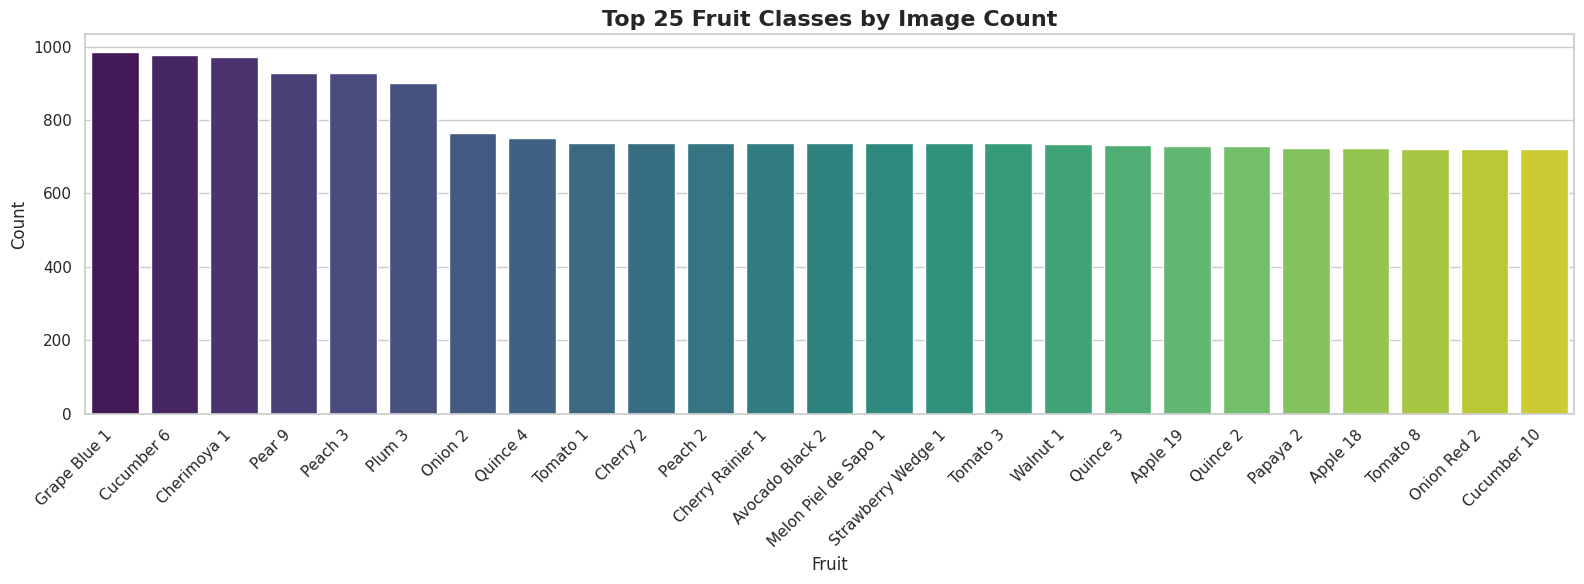

In [3]:
classes = sorted(os.listdir(train_dir))
class_counts = []

for c in classes:
    class_dir = os.path.join(train_dir, c)
    if os.path.isdir(class_dir):
        class_counts.append((c, len(os.listdir(class_dir))))

df_counts = pd.DataFrame(class_counts, columns=['Fruit', 'Count'])
df_counts = df_counts.sort_values(by='Count', ascending=False)

print(f"Total Fruit Classes: {len(classes)}")
print(f"Total Training Images: {df_counts['Count'].sum()}")

plt.figure(figsize=(16, 6))
sns.barplot(data=df_counts.head(25), x='Fruit', y='Count', palette='viridis')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.title('Top 25 Fruit Classes by Image Count', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

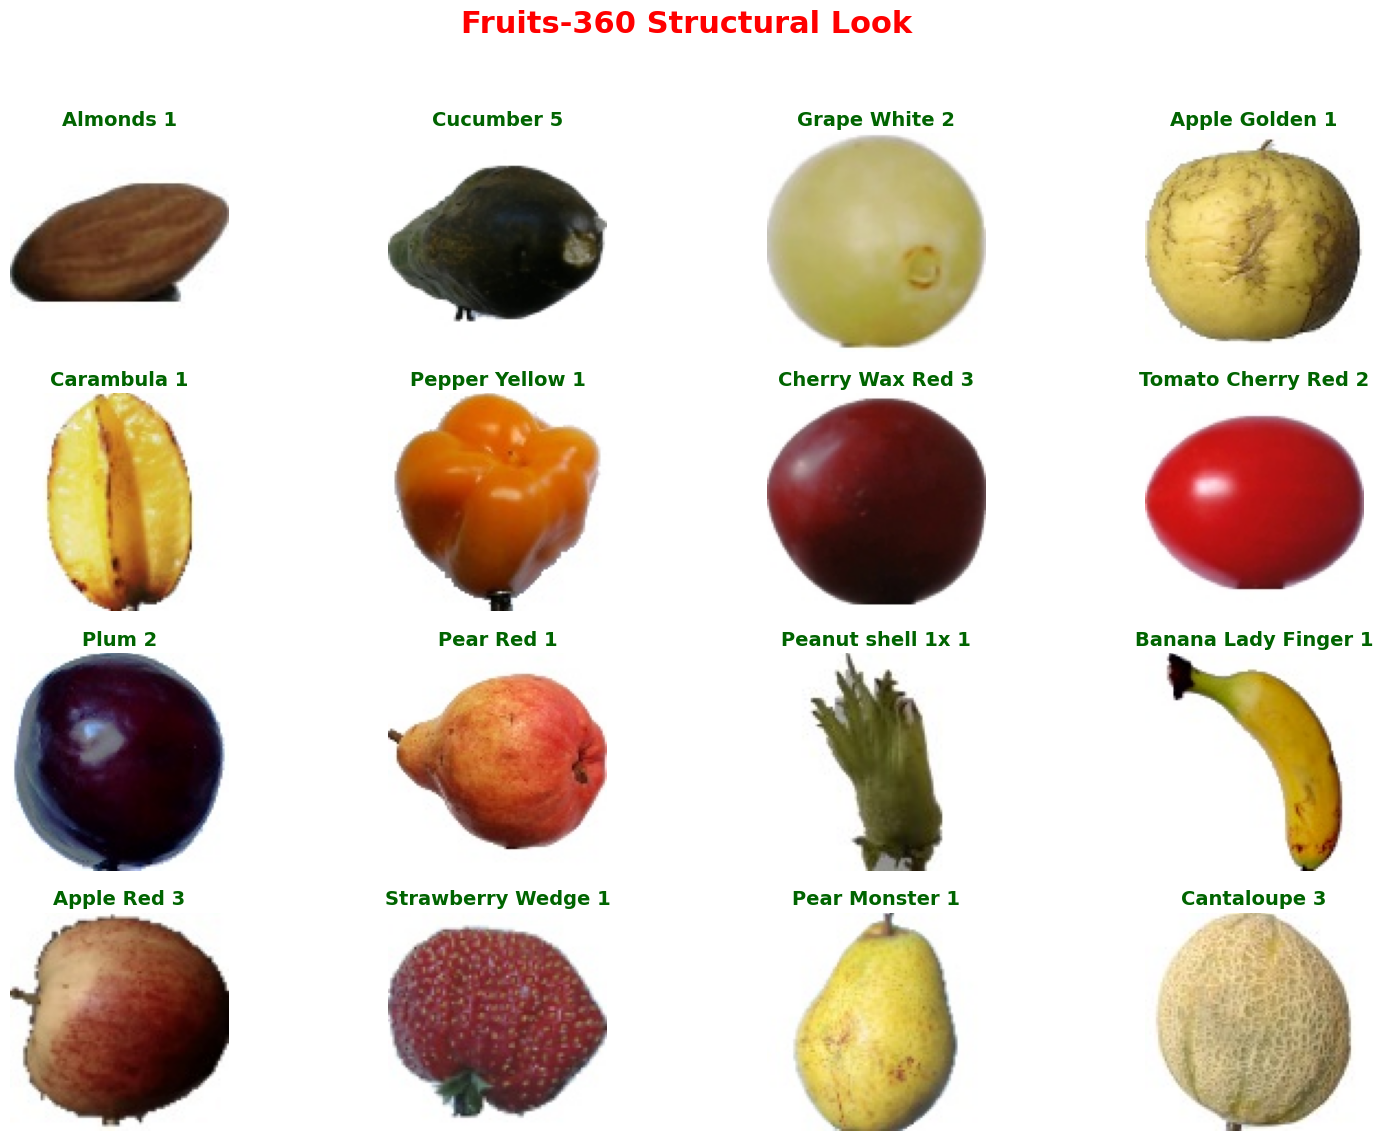

In [4]:
# Visualizing Sample Images
plt.figure(figsize=(16, 12))
sample_classes = random.sample(classes, 16)

for i, c in enumerate(sample_classes):
    class_dir = os.path.join(train_dir, c)
    images = os.listdir(class_dir)
    if not images: continue
        
    img_path = os.path.join(class_dir, random.choice(images))
    img = load_img(img_path)
    
    plt.subplot(4, 4, i + 1)
    plt.imshow(img)
    plt.title(c, fontsize=14, color='darkgreen', fontweight='bold')
    plt.axis('off')

plt.suptitle("Fruits-360 Structural Look", fontsize=22, fontweight='bold', color='red')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

<a id="fe"></a>
## ⚡️ 4. Ultra-Fast Data Pipelines (`tf.data`)
We abandon `ImageDataGenerator` immediately. The CPU completely throttles the Kaggle GPU when loading 70,000 images batch-by-batch.

Instead, we use `tf.keras.utils.image_dataset_from_directory`, map the IO strictly utilizing `tf.data.AUTOTUNE`, and `.prefetch()` batches continuously so the GPU never waits a single millisecond.

In [5]:
IMG_SIZE = (100, 100)
BATCH_SIZE = 128      # GPU can comfortably handle massive batches now

print("Building Ultra-Fast Training Dataset Pipeline...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

print("\nBuilding Ultra-Fast Validation Dataset Pipeline...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

print("\nBuilding Testing Dataset...")
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

# ----------------- THE SPEED SECRET ------------------
AUTOTUNE = tf.data.AUTOTUNE

# To prevent Kaggle RAM OOM (Kernel Dying) on massive datasets, we strictly rely on Prefetching without memory Caching.
# Prefetch continuously loads the next batch onto the GPU while the current batch is processing.
train_ds = train_ds.shuffle(2000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)
print("\n✅ Hardware Prefetching Activated (RAM Optimized)!")

Building Ultra-Fast Training Dataset Pipeline...
Found 132448 files belonging to 253 classes.
Using 105959 files for training.


I0000 00:00:1772994080.275287      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



Building Ultra-Fast Validation Dataset Pipeline...
Found 132448 files belonging to 253 classes.
Using 26489 files for validation.

Building Testing Dataset...
Found 44138 files belonging to 253 classes.

✅ Hardware Prefetching Activated (RAM Optimized)!


<a id="model"></a>
## 🧠 5. Architecture: MobileNetV2 with GPU Augmentation
Because our loading pipeline is pure `AUTOTUNE`, we move **Feature Engineering (Data Augmentation)** *inside* the model using `tf.keras.Sequential`. This causes the augmentation to be calculated natively by the GPU hardware exactly at runtime.

In [6]:
# GPU-Accelerated Data Augmentation Block
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.2),
    RandomZoom(0.2),
    RandomTranslation(height_factor=0.2, width_factor=0.2),
])

# Pre-trained Base Architecture
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=IMG_SIZE + (3,))
base_model.trainable = False  # Freeze for Phase 1

# Assemble Fully Native Model
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))

# 1. Augment
x = data_augmentation(inputs)

# 2. Preprocess accurately for MobileNetV2 (-1 to 1 pixel scaling)
x = preprocess_input(x)

# 3. Run MobileNet Core
x = base_model(x, training=False)

# 4. Custom Top Classification Head
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=inputs, outputs=predictions)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
              loss='sparse_categorical_crossentropy',   # using sparse because tf.data natively loads labels as integers
              metrics=['accuracy'])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 253)            │       129,789 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,043,645 (11.61 MB)

 Trainable params: 785,661 (3.00 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

<a id="phase1"></a>
## 🚀 6. Training Phase 1: Classification Head
Wait and see how unbelievably fast this executes now compared to the old generator approach!

In [7]:
callbacks_p1 = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ModelCheckpoint('model_phase1.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

EPOCHS_P1 = 15

history_p1 = model.fit(
    train_ds,
    epochs=EPOCHS_P1,
    validation_data=val_ds,
    callbacks=callbacks_p1
)

Epoch 1/15


I0000 00:00:1772994275.972064     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


828/828 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3850 - loss: 2.7053
Epoch 1: val_accuracy improved from -inf to 0.82925, saving model to model_phase1.keras
828/828 ━━━━━━━━━━━━━━━━━━━━ 210s 76ms/step - accuracy: 0.3852 - loss: 2.7041 - val_accuracy: 0.8292 - val_loss: 0.5338 - learning_rate: 0.0010
Epoch 2/15
827/828 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7070 - loss: 0.9390
Epoch 2: val_accuracy improved from 0.82925 to 0.85692, saving model to model_phase1.keras
828/828 ━━━━━━━━━━━━━━━━━━━━ 59s 44ms/step - accuracy: 0.7070 - loss: 0.9388 - val_accuracy: 0.8569 - val_loss: 0.4225 - learning_rate: 0.0010
Epoch 3/15
827/828 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7453 - loss: 0.8027
Epoch 3: val_accuracy improved from 0.85692 to 0.86859, saving model to model_phase1.keras
828/828 ━━━━━━━━━━━━━━━━━━━━ 61s 44ms/step - accuracy: 0.7453 - loss: 0.8026 - val_accuracy: 0.8686 - val_loss: 0.3820 - learning_rate: 0.0010
Epoch 4/15
827/828 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/st

<a id="phase2"></a>
## 🔬 7. Training Phase 2: Fine-Tuning

In [8]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

callbacks_p2 = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint('model_phase2_best.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
]

EPOCHS_P2 = 10

print("\n--- Unfrozen Base. Phase 2 Tuning Activated! ---")
history_p2 = model.fit(
    train_ds,
    epochs=EPOCHS_P2,
    validation_data=val_ds,
    callbacks=callbacks_p2
)


--- Unfrozen Base. Phase 2 Tuning Activated! ---
Epoch 1/10
828/828 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5836 - loss: 1.6065
Epoch 1: val_accuracy improved from -inf to 0.90607, saving model to model_phase2_best.keras
828/828 ━━━━━━━━━━━━━━━━━━━━ 84s 61ms/step - accuracy: 0.5837 - loss: 1.6059 - val_accuracy: 0.9061 - val_loss: 0.2707
Epoch 2/10
828/828 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7871 - loss: 0.6655
Epoch 2: val_accuracy improved from 0.90607 to 0.92140, saving model to model_phase2_best.keras
828/828 ━━━━━━━━━━━━━━━━━━━━ 73s 59ms/step - accuracy: 0.7871 - loss: 0.6654 - val_accuracy: 0.9214 - val_loss: 0.2200
Epoch 3/10
828/828 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8295 - loss: 0.5200
Epoch 3: val_accuracy improved from 0.92140 to 0.92635, saving model to model_phase2_best.keras
828/828 ━━━━━━━━━━━━━━━━━━━━ 75s 60ms/step - accuracy: 0.8295 - loss: 0.5199 - val_accuracy: 0.9263 - val_loss: 0.2043
Epoch 4/10
828/828 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms

<a id="eval"></a>
## 📈 8. Model Evaluation & Metrics

345/345 ━━━━━━━━━━━━━━━━━━━━ 61s 177ms/step - accuracy: 0.9151 - loss: 0.4645

🎉 Absolute Final Test Accuracy: 91.46%


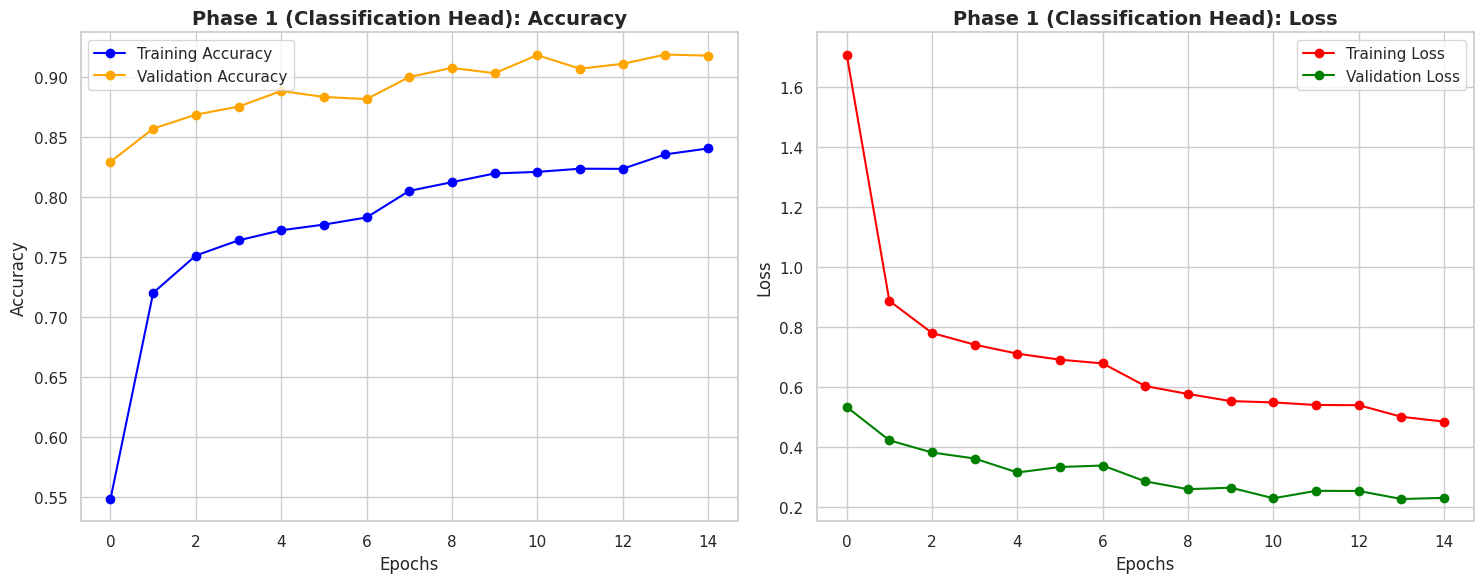

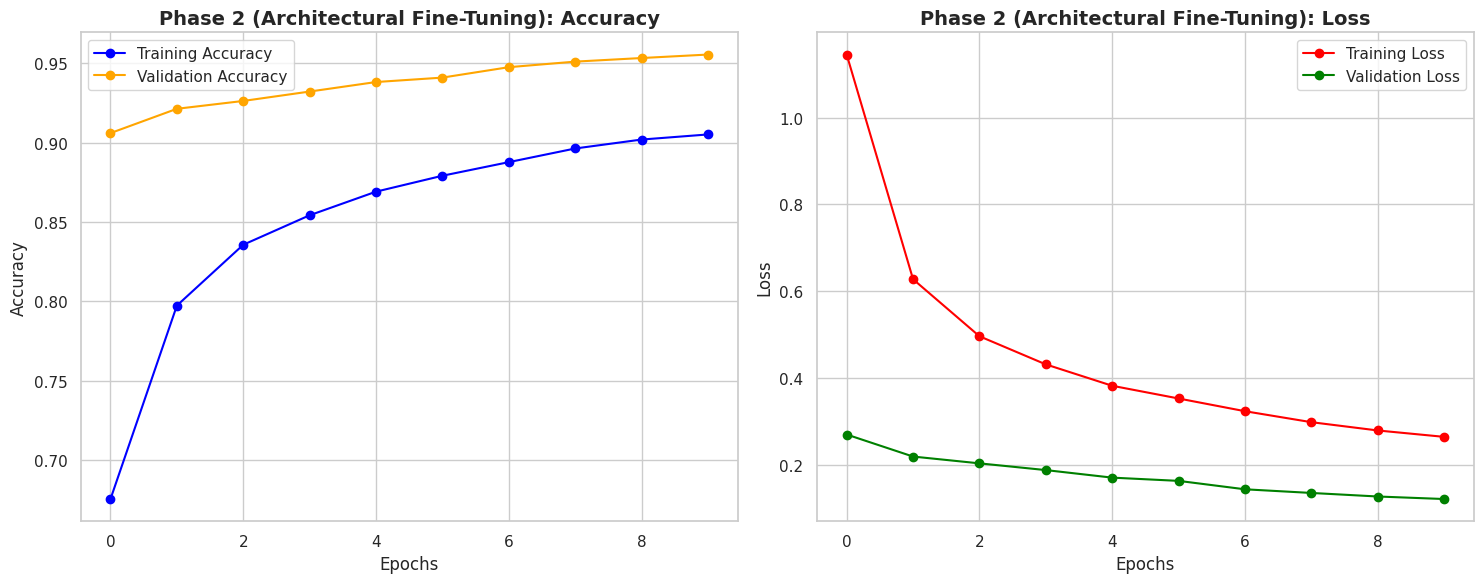

In [9]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\n🎉 Absolute Final Test Accuracy: {test_acc*100:.2f}%")

def plot_training(history, title_prefix):
    plt.figure(figsize=(15, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o', color='blue')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o', color='orange')
    plt.title(f'{title_prefix}: Accuracy', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss', marker='o', color='red')
    plt.plot(history.history['val_loss'], label='Validation Loss', marker='o', color='green')
    plt.title(f'{title_prefix}: Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_training(history_p1, "Phase 1 (Classification Head)")
if 'history_p2' in locals() and len(history_p2.history['accuracy']) > 0:
    plot_training(history_p2, "Phase 2 (Architectural Fine-Tuning)")

<a id="export"></a>
## 📦 9. Deployment: Exporting to TFLite for Flutter

In [ ]:
with open('fruit_labels.txt', 'w') as f:
    f.write('\n'.join(class_names))

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('fruits_model.tflite', 'wb') as f:
    f.write(tflite_model)

size_mb = os.path.getsize('fruits_model.tflite') / (1024 * 1024)
print(f"\n💾 Flutter Core Model Optimized Size: {size_mb:.2f} MB")
print("\n✅ Go to the Output Panel in Kaggle, download 'fruits_model.tflite' & 'fruit_labels.txt', and drag them into your Flutter assets folder!")